# 一、前言

VAE 的核心目标函数 ELBO 长这样——<br>
$ELBO = \mathbb{E}_{z\sim q}[\log p(x|z)] - KL(q(z|x) \| p(z))$<br>
明天要啃这个式子，其中 KL 项就是今天要搞定的一半。今天不动 PyTorch，只做数学直觉 + 代码验证，明天才能不被 ELBO 劝退。

# 二、代码验证

## 1.先认识高斯——μ 和 σ 各管什么

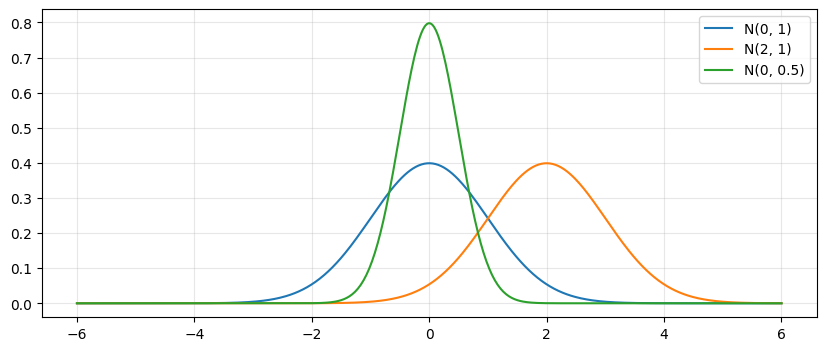

In [3]:
import numpy as np
import matplotlib.pyplot as plt
def gauss_pdf(x, mu, sigma):
    """高斯概率密度函数。sigma 不能为 0，否则除以 0"""
    return 1 / (sigma * np.sqrt(2 * np.pi)) * np.exp(-(x - mu) ** 2 / (2 * sigma ** 2))
x = np.linspace(-6, 6, 500)   # 在区间 [-6,\;6] 之间，均匀取出 500 个横坐标点。
plt.figure(figsize = (10, 4))
for mu, sigma, label in [(0, 1, 'N(0, 1)'), (2, 1, 'N(2, 1)'), (0, 0.5, 'N(0, 0.5)')]:
    plt.plot(x, gauss_pdf(x, mu, sigma), label = label)
plt.legend()
plt.grid(alpha = 0.3)
plt.show()

为什么先看这个：VAE 里 p(z) 固定是 N(0,1)，q(z|x) 是 N(μ, σ²)——μ 管分布挪到哪(改变峰值横坐标)，σ 管分布胖不胖(改变离散程度)。不先建立这个直觉，明天看到 encoder 输出"均值+方差"会不知道为什么是俩头。<br>
高斯 PDF **y 轴不是概率**，是概率密度；曲线下总面积恒等于 1。<br>
这段代码画出 **3 条一维高斯（正态分布）概率密度曲线**<br>
$f(x)=\frac{1}{\sigma\sqrt{2\pi}}\exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$ <br>
$\mu$：均值，控制曲线**左右平移**<br>
$\sigma$：标准差，控制曲线**胖瘦宽窄**<br>
三条曲线：<br>
1. N(0,1)：标准正态分布，$\mu=0,\sigma=1$<br>
2. N(2,1)：均值右移到 2，宽度不变<br>
3. N(0,0.5)：均值 0，标准差更小 → 曲线更瘦、更高、更集中

## 2.离散 KL 散度——从信息论入门

In [7]:
def kl_discrete(P, Q):
    """KL(P||Q) = Σ P(x) log(P(x)/Q(x))。Q 里不能有 0 且 P 有值的位置"""
    return np.sum(P * np.log(P / Q))    # np.log() 在 NumPy 中固定代表 ln(自然对数，底数 e)
P = np.array([0.6, 0.4])    # 真实分布, P：事件 1 概率 0.6，事件 2 概率 0.4
Q = np.array([0.5, 0.5])    # 用 Q 去近似 P, Q：均匀分布，两个事件各 0.5
print(f'KL(P||Q) = {kl_discrete(P, Q):.4f}')
print(f'KL(P||Q) = 0 当且仅当 P = Q:{kl_discrete(P, P):.4f}')

KL(P||Q) = 0.0201
KL(P||Q) = 0 当且仅当 P = Q:0.0000


为什么：KL 的直觉是"如果用 Q 来编码来自 P 的数据，平均多花多少 bit"。P=Q 时代价为 0。这个"代价/距离"的直觉，就是 VAE 里"让 q(z|x) 别偏离 p(z) 太远"的意思。

KL‑散度（离散）公式<br>
$D_{\text{KL}}(P\parallel Q)=\sum_{x} P(x)\log\left(\frac{P(x)}{Q(x)}\right)$ <br>
含义：衡量**用分布 Q 去近似真实分布 P**的时候，带来的额外信息量（损失）。<br>
注意关键点：<br>
KL(P||Q) **不是对称**：$D_{KL}(P||Q)\neq D_{KL}(Q||P)$<br>
KL ≥ 0<br>
当且仅当 P 和 Q 完全一样时，KL = 0<br>
交叉熵损失本质 = 熵 (P) + KL (P||Q)，最小化交叉熵等价于最小化 KL 散度

## 3.连续高斯之间的 KL（VAE 直接要用的公式）

In [8]:
def kl_gauss(mu1, sigma1, mu2, sigma2):
    """KL(N(μ1,σ1²) || N(μ2,σ2²)) 闭式解，VAE 里直接抄这个公式"""
    return np.log(sigma2 / sigma1) + (sigma1 ** 2 + (mu1 - mu2) ** 2) / (2 * sigma2 ** 2) - 0.5
print(kl_gauss(0, 1, 0, 1))      # 相同分布 → 0
print(kl_gauss(0, 1, 0, 2))      # 只变 σ
print(kl_gauss(0, 1, 1, 1))      # 只变 μ

0.0
0.3181471805599453
0.5


为什么：这是明天 VAE 代码里 KLD = -0.5 * torch.sum(1 + log_var - mu**2 - log_var.exp()) 那个一行的推导来源——p(z)=N(0,1) 代入后化简的结果。今天先把它当黑盒验证：结果永远 ≥ 0，相同时为 0。

一维高斯 KL‑散度 闭式公式<br>
$D_{\mathrm{KL}}\big(\mathcal{N}(\mu_1,\sigma_1^2)\,\|\,\mathcal{N}(\mu_2,\sigma_2^2)\big)$ <br>
$\boldsymbol{D_{\text{KL}}=\ln\frac{\sigma_2}{\sigma_1}+\frac{\sigma_1^2+(\mu_1-\mu_2)^2}{2\,\sigma_2^2}-\frac12}$ <br>
> 公式用的是**自然对数 ln**，和代码里 `np.log`（numpy ln）匹配。<br>
> 注意：这里传入的是 **标准差 σ**，不是方差 $\sigma^2$。

VAE 的正则项就是：<br>
$D_{\mathrm{KL}}\big(\,q_\phi(z|x)\,\|\,p(z)\,\big)$<br>
先验 $p(z)$ 固定为标准正态 $\mathcal{N}(0,1)$<br>
也就是：$\mu_2=0,\ \sigma_2=1$<br>
代入上面公式就得到 VAE 最常见的 KL 损失：<br>
$D_{\mathrm{KL}}=\frac12\big(\sigma_1^2+\mu_1^2-\ln(\sigma_1^2)-1\big)$
> 注意：上面这个版本**输入的是方差**，和当前函数输入标准差不一样，不要搞混。

## 4.KL 不对称——方向决定行为

KL(P||Q) = 0.9175    (窄 -> 宽)
KL(Q||P) = 6.1137    (宽 -> 窄)


/home/wsl2/anaconda3/envs/dl/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 31364 (\N{CJK UNIFIED IDEOGRAPH-7A84}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/wsl2/anaconda3/envs/dl/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 23485 (\N{CJK UNIFIED IDEOGRAPH-5BBD}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


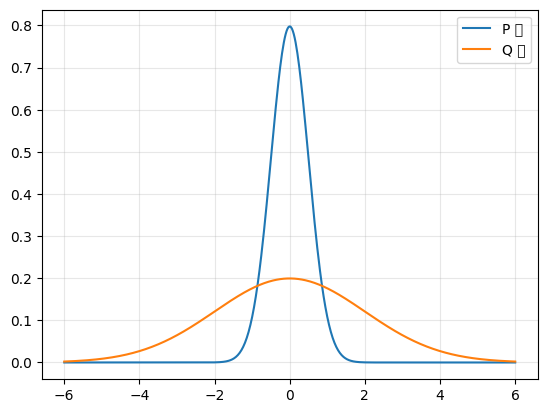

In [10]:
# 一个窄一个宽，正反两个方向
mu1, s1, mu2, s2 =0, 0.5, 0, 2
print(f'KL(P||Q) = {kl_gauss(mu1, s1, mu2, s2):.4f}    (窄 -> 宽)')
print(f'KL(Q||P) = {kl_gauss(mu2, s2, mu1, s1):.4f}    (宽 -> 窄)')
x = np.linspace(-6, 6, 500)
plt.plot(x, gauss_pdf(x, mu1, s1), label = 'P 窄')
plt.plot(x, gauss_pdf(x, mu2, s2), label = 'Q 宽')
plt.legend()
plt.grid(alpha = 0.3)
plt.show()

为什么：两个方向不相等——KL 不是距离（距离必须对称）。VAE 里用的是 KL(q||p) 方向，含义是"q 去拟合 p 时不能漏掉 p 覆盖的区域"。今天记住"不对称"这个事实即可，方向直觉明天讲 ELBO 时展开。

$P=\mathcal{N}(\mu_1=0,\; \sigma_1=0.5)$：**窄高斯**，数值集中在 0 附近<br>
$Q=\mathcal{N}(\mu_2=0,\; \sigma_2=2)$：**宽高斯**，数值范围更广

$D_{\mathrm{KL}}(P\|Q)$ 窄 → 宽<br>
用宽分布 Q 去近似原本很窄的真实分布 P，代价 0.9175<br>
$D_{\mathrm{KL}}(Q\|P)$ 宽 → 窄<br>
用一个很窄的分布 P 去近似一个很宽的真实分布 Q，代价暴涨到 6.1137<br>
 **直观结论：KL‑散度严重不对称！**  <br>
$\boldsymbol{D_{\mathrm{KL}}(P\|Q)\neq D_{\mathrm{KL}}(Q\|P)}$

为什么差距这么大（笔记核心）<br>
KL 公式：$D_{\mathrm{KL}}(P\|Q)=\sum P(x)\log\frac{P(x)}{Q(x)}$ <br>
P（真实）很窄：它的概率质量几乎全部集中在中心一小段；在这片区域 Q（宽）也有不小的概率，惩罚不大。<br>
Q（真实）很宽：它在远离中心点的地方也有不少概率；但近似分布 P（窄）在远处几乎等于 0。<br>
$\log(P(x)/Q(x))$ 就会产生巨大的惩罚项 → KL 数值飙升。<br>
> 一句话总结：<br>
> **用窄分布去拟合宽分布代价很高，反过来就轻松很多。**

启示（重点）<br>
VAE 损失： $\mathcal{L}= \text{重构损失} + D_{\mathrm{KL}}\big(q(z|x)\,\|\,p(z)\big)$ <br>
$q(z|x)$：编码器输出，学到的后验<br>
$p(z)$：先验 $\mathcal{N}(0,1)$（中等宽度）<br>
KL 项含义：**强制编码器学到的分布去靠近先验**。<br>
后验 || 先验，顺序不能颠倒

## 5.蒙特卡洛估计 KL——重参数化的雏形

In [13]:
def kl_mc(mu1, sigma1, mu2, sigma2, n_samples=200000):
    """从 P 采样，用样本平均估计 E[logP - logQ]。不做近似误差校验别信结果"""
    z = np.random.normal(mu1, sigma1, n_samples)   # 从 P 采 n_samples 个样本
    logp = -np.log(sigma1) - 0.5*np.log(2*np.pi) - (z-mu1)**2/(2*sigma1**2)
    logq = -np.log(sigma2) - 0.5*np.log(2*np.pi) - (z-mu2)**2/(2*sigma2**2)
    return np.mean(logp - logq)   # 返回样本均值，作为期望的估计值
exact = kl_gauss(0, 1, 1, 1)
print(f"闭式解: {exact:.4f}   蒙特卡洛估计: {kl_mc(0, 1, 1, 1):.4f}")
# 闭式解析解为 0.5，蒙特卡洛用 20 万个样本去逼近这个 0.5，最终结果能够差距不大

闭式解: 0.5000   蒙特卡洛估计: 0.5023


为什么这是重参数化的雏形：KL 写成期望 E_{x~P}[logP - logQ]，用"从 P 采样 + 样本平均"来近似——"期望 = 采样平均"这个思想，明天就是重参数化（从 q(z|x) 采样算梯度）的全部秘密。

KL‑散度定义（期望形式）：<br>
$D_{\mathrm{KL}}(P\|Q)=\mathbb{E}_{z\sim P}\left[\log\frac{P(z)}{Q(z)}\right]
=\mathbb{E}_{z\sim P}\big[\log P(z)-\log Q(z)\big]$  <br>
**蒙特卡洛 (Monte‑Carlo) 思想**：<br>
不能解析求解时，就**从分布 P 抽出大量样本 z**，然后取样本平均值去逼近数学期望。

logp = -np.log(sigma1) - 0.5*np.log(2 * np.pi) - (z-mu1)**2/(2 * sigma1**2) <br>
一维高斯对数概率密度 $\log P(z)$：<br>
$p(z)=\frac{1}{\sigma_1\sqrt{2\pi}}\exp\left(-\frac{(z-\mu_1)^2}{2\sigma_1^2}\right)$ <br>
两边取自然对数：<br>
$\log p(z)=-\log\sigma_1-\frac12\log(2\pi)-\frac{(z-\mu_1)^2}{2\sigma_1^2}$  <br>
(这里的 log 其实是 ln)

| 方式 | kl_gauss (闭式解) | kl_mc (蒙特卡洛采样) |
| --- | --- | --- |
| 原理 | 使用高斯 KL 推导出来的数学公式，**无误差** | 采样求期望均值，**随机近似** |
| 速度 | 瞬间算出，不需要采样 | 需要生成大量样本，慢 |
| 使用场景 | 两个都是一维高斯，可以用闭式 | \(P,Q\) 很复杂，没有解析公式，只能采样估计 |

# 三、李宏毅 VAE笔记

李宏毅《VAE（变分自编码器）》核心内容总结

1. 从 AE 到 VAE 的问题链（先直觉后数学）<br>
 PCA（线性降维）→ 用神经网络替换 → Deep Auto-Encoder（非线性降维）<br>
 AE 的致命缺陷：code 空间是"离散的点"，点与点之间没有意义<br>
  例：满月图 → code A，半月图 → code B；在 A、B 中间采样一个点喂给 decoder，<br>
  得到的不是"3/4 月亮"，而是模糊乱码——因为非线性编码导致中间点毫无规律<br>
 结论：AE 只能"压缩-重建"，不能"生成"新样本

2. VAE 的核心改动：给 code 加噪声<br>
 编码不再是单个点，而是"均值 μ + 噪声"：z = μ + exp(σ) ⊙ ε<br>
  exp(σ)：保证噪声权重恒为正<br>
  ε：标准正态采样<br>
 效果：每个样本的 code 从一个点"撑开"成一个分布，覆盖失真区域<br>
  两个分布的交叉区域被 decoder 训练成"两种图的折中"→ 生成有意义的新样本<br>
 把噪声"无限拉长"（每个样本覆盖整个空间，中心概率最高）→ code 从离散点变连续分布
  ——这就是"变分"的直觉起点

3. 损失函数为什么是两项<br>
 第一项（重构损失）：decoder 要把加了噪声的 code 还原成原图<br>
 第二项（KL 项，李宏毅版：minimize exp(σ) - (1 + σ)）：<br>
 防止 encoder 作弊——如果不加，encoder 会把 σ 推到负无穷（噪声=0），<br>
 等于退化成 AE，重构效果最好但失去生成能力。KL 项逼 σ 不要走极端

4. 数学推导主线（李宏毅讲的核心逻辑）<br>
 理论根基：高斯混合模型 GMM——任何分布 ≈ 若干高斯叠加<br>
 把离散的"高斯编号 m"换成连续变量 z ~ N(0,1)：<br>
 P(x) = ∫ P(x|z)·P(z) dz<br>
 难点：P(x|z) 未知 → 引入两个神经网络<br>
  Decoder：拟合 P(x|z)（生成网络）<br>
  Encoder：拟合 q(z|x)（推断网络），用于辅助求解<br>
 关键推导（）：<br>
  log P(x) = ELBO + KL(q(z|x) || P(z|x))<br>
  因为 KL ≥ 0，所以 ELBO 是 log P(x) 的下界 → 最大化 log P(x) ≈ 最大化 ELBO
  ELBO 展开成两项：<br>
  ELBO = E_{q(z|x)}*[log P(x|z)] - KL(q(z|x) || P(z))<br>
--------------------｜------------------｜<br>
-----------------重构损失------------KL 项（N(0,1) 先验）<br>
--------------（第一项损失）--------（第二项损失的来源）<br>
  
5. 两个关键概念<br>
 "变分"是什么：用简单的分布 q 去近似复杂的分布 p（变分推断）<br>
 为什么 encoder 输出的是 μ/σ：因为约定 z 服从高斯，损失函数按高斯 PDF 推导，<br>
 梯度下降后 z 的分布确实被"逼"向高斯——不是玄学，是损失函数定义的

6. 与 AE 的本质区别<br>
AE 的隐层是点（无分布约束），VAE 的隐层是分布（高斯），所以 AE 只能重建，VAE 能生成"训练集中不存在但合理"的新样本

# 四、测试小结

1. kl_gauss(0, 1, 0, 1) 为什么等于 0？如果 σ1=σ2=1 但 μ1=3, μ2=0，KL 是多少？（提示：套公式心算）<br>
因为分子分母相同，则为 1，ln1 等于 0，剩余一项等于 0.5，再减去公式里的常数项 0.5，那么整体值就是为 0；4.5

2. 明天 VAE 里为什么是 KL(q(z|x) || p(z)) 而不是反过来的 KL(p(z) || q(z|x))？（提示：想想 Cell 4 的方向直觉 + "谁在近似谁"）<br>
梯度能传播（首要理由）：KL(q||p) = E_{z~q}[log q(z) - log p(z)]，期望按 q 采样——q 的参数 μ、σ 参与采样（重参数化），梯度能传回 encoder。反过来的 KL(p||q) 期望按固定的 p=N(0,1) 采样，梯度传不到 q，encoder 直接没法训练。<br>
变分推断的标准形式：log p(x) = ELBO + KL(q(z|x)||p(z|x)) 是数学推导出来的分解，KL 项天然就是这个方向（用 q 近似后验 p(z|x)）。<br>
zero-avoiding：KL(q||p) 惩罚"q 在 p 覆盖不到的地方有质量"，逼 q 覆盖先验支撑区，采样不容易跑到 decoder 没训练过的区域；反方向是 zero-forcing，允许 q 只覆盖 p 一部分 → 容易 mode collapse（生成塌缩到几种样本）。